# Bài tập buổi 13: Xây dựng mạng MLP trên EMNIST

Đề bài : Xây dựng pipeline huấn luyện một mạng MLP (Multi-Layer Perceptron) để phân loại **chữ cái in hoa** trong dataset **EMNIST** (A–Z, 26 lớp).

Mục tiêu:
- Tải và chuẩn bị dữ liệu EMNIST bằng `torchvision`.
- Định nghĩa mô hình MLP bằng `nn.Module`.
- Viết vòng lặp huấn luyện và đánh giá.
- Trực quan hóa kết quả và lưu mô hình.

Kết quả tham khảo: MLP đơn giản này thường đạt khoảng **85–90%** accuracy trên tập test.

## 1. Import và cấu hình

Import các thư viện cần thiết rồi đặt các tham số huấn luyện.

Gợi ý: `BATCH_SIZE = 256`, `EPOCHS = 5`, `LEARNING_RATE = 1e-3`. Chọn `DEVICE` là `cuda` nếu có GPU, ngược lại dùng `cpu`.

In [1]:
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torch.optim import AdamW
from torchvision import datasets, transforms

BATCH_SIZE = 256
EPOCHS = 5
LEARNING_RATE = 1e-3
DATA_DIR = './data'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

torch.manual_seed(0)

print(f'PyTorch: {torch.__version__}')
print(f'Thiết bị: {DEVICE}')

PyTorch: 2.13.0+cu130
Thiết bị: cuda


## 2. Dataset và DataLoader

Tải dataset EMNIST với `split='letters'` (26 lớp chữ cái in hoa A–Z, ảnh xám 28×28).

- Dùng `transforms.Compose([transforms.ToTensor()])` để đổi ảnh thành tensor.
- Tách tập train gốc (124.800 mẫu) thành **100.000 mẫu train** và **24.800 mẫu validation**.
- Tạo 3 `DataLoader` với `batch_size=BATCH_SIZE`; chỉ `train_loader` cần `shuffle=True`.

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

full_train = datasets.EMNIST(DATA_DIR, split='letters', train=True, transform=transform, download=True)
test_set = datasets.EMNIST(DATA_DIR, split='letters', train=False, transform=transform, download=True)

# Tách full_train thành train_set và val_set
train_set, val_set = random_split(full_train, [100000, 24800])

# Tạo DataLoader
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

print(len(train_set), len(val_set), len(test_set))

100000 24800 20800


## 3. Khám phá dữ liệu

In shape của một batch rồi vẽ vài ảnh đầu tiên để xem dữ liệu trông như thế nào.

Lưu ý: nhãn là số nguyên 0–25, tương ứng với chữ cái A–Z. Có thể đổi sang ký tự bằng `chr(nhãn + ord('A'))`.

Batch ảnh : torch.Size([256, 1, 28, 28])
Batch nhãn: torch.Size([256])


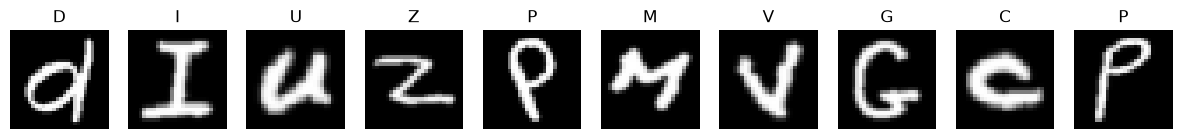

In [3]:
batch_images, batch_labels = next(iter(train_loader))
print('Batch ảnh :', batch_images.shape)
print('Batch nhãn:', batch_labels.shape)

# Vẽ 10 ảnh đầu tiên của batch
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i in range(10):
    img = batch_images[i].squeeze().transpose(0, 1)
    label_char = chr(batch_labels[i].item() - 1 + ord('A'))
    
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(label_char)
    axes[i].axis('off')
    
plt.show()

## 4. Định nghĩa MLP

Xây dựng lớp `EMNISTMLP` kế thừa `nn.Module`.

Gợi ý cấu trúc: `Flatten` → `Linear(784, 128)` → `ReLU` → `Linear(128, 26)`.
Chú ý: 784 = 28×28 (kích thước ảnh sau khi dẹt), 26 = số lớp chữ cái.

In [4]:
class EMNISTMLP(nn.Module):
    def __init__(self):
        super().__init__()
        # Định nghĩa các layer
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(784, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 26)

    def forward(self, images):
        # Cho images đi qua các layer tuần tự
        x = self.flatten(images)
        x = self.fc1(x)
        x = self.relu(x)
        logits = self.fc2(x)
        return logits

model = EMNISTMLP().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

print(model)

EMNISTMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=26, bias=True)
)


## 5. Vòng lặp huấn luyện và đánh giá

Viết 2 hàm:

- `train_one_epoch`: với mỗi batch, thực hiện `zero_grad` → forward → tính loss → `backward` → `step`. Cộng dồn loss và số dự đoán đúng.
- `evaluate`: giống vòng lặp trên nhưng **không cập nhật trọng số**, dùng `model.eval()` và `torch.no_grad()`.

Cả hai hàm trả về `(loss trung bình, accuracy)`.

In [5]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        
        # Kéo nhãn từ 1-26 về 0-25
        labels = labels - 1  
        
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_samples += images.size(0)

    return total_loss / total_samples, total_correct / total_samples

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            
            # Kéo nhãn từ 1-26 về 0-25
            labels = labels - 1  
            
            logits = model(images)
            loss = criterion(logits, labels)

            total_loss += loss.item() * images.size(0)
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_samples += images.size(0)

    return total_loss / total_samples, total_correct / total_samples

## 6. Huấn luyện

Chạy vòng lặp qua `EPOCHS` epoch. Mỗi epoch: train 1 epoch trên `train_loader`, đánh giá trên `val_loader`, lưu loss/accuracy vào các list và in kết quả.

In [6]:
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(model, val_loader, criterion)
    
    # Lưu lại lịch sử
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    
    print(f'Epoch {epoch}: train loss={train_loss:.4f}, val loss={val_loss:.4f}, train acc={train_acc:.2%}, val acc={val_acc:.2%}')

Epoch 1: train loss=1.2334, val loss=0.8672, train acc=66.31%, val acc=75.40%
Epoch 2: train loss=0.7317, val loss=0.6606, train acc=79.09%, val acc=80.81%
Epoch 3: train loss=0.5754, val loss=0.5513, train acc=83.38%, val acc=83.70%
Epoch 4: train loss=0.4919, val loss=0.4890, train acc=85.54%, val acc=85.46%
Epoch 5: train loss=0.4394, val loss=0.4563, train acc=86.88%, val acc=86.23%


## 7. Đánh giá và trực quan hóa

1. Vẽ 2 biểu đồ cạnh nhau: **Loss** và **Accuracy** theo epoch (so sánh train vs val).
2. Đánh giá mô hình trên `test_loader` (tập chưa từng dùng khi huấn luyện).
3. Lấy 1 batch từ `test_loader`, vẽ 10 ảnh với nhãn thật và nhãn dự đoán (xanh = đúng, đỏ = sai).

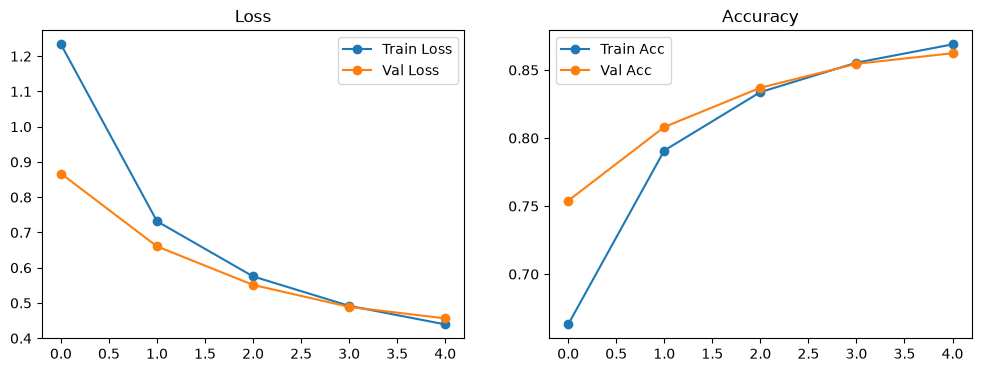

Test loss=0.4645, test accuracy=86.21%


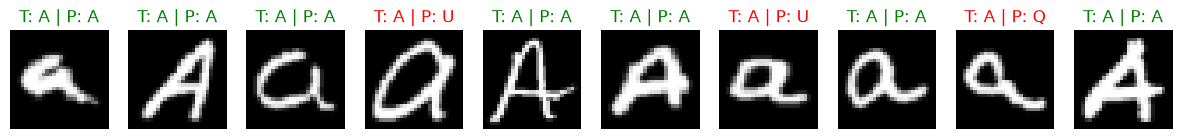

In [7]:
# 1. Vẽ đồ thị Loss và Accuracy theo epoch
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label='Train Loss', marker='o')
ax1.plot(val_losses, label='Val Loss', marker='o')
ax1.set_title('Loss')
ax1.legend()

ax2.plot(train_accuracies, label='Train Acc', marker='o')
ax2.plot(val_accuracies, label='Val Acc', marker='o')
ax2.set_title('Accuracy')
ax2.legend()

plt.show()

# 2. Đánh giá model trên test set
test_loss, test_accuracy = evaluate(model, test_loader, criterion)
print(f'Test loss={test_loss:.4f}, test accuracy={test_accuracy:.2%}')

# 3. Trực quan hóa batch từ test_loader
test_batch_images, test_batch_labels = next(iter(test_loader))
test_batch_images = test_batch_images.to(DEVICE)

model.eval()
with torch.no_grad():
    predictions = model(test_batch_images).argmax(dim=1).cpu()

test_batch_images = test_batch_images.cpu()

fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i in range(10):
    img = test_batch_images[i].squeeze().transpose(0, 1)
    true_label = chr(test_batch_labels[i].item() - 1 + ord('A'))
    pred_label = chr(predictions[i].item() + ord('A'))
    
    # Chỉnh màu sắc theo độ chính xác
    color = 'green' if true_label == pred_label else 'red'
    
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f'T: {true_label} | P: {pred_label}', color=color)
    axes[i].axis('off')
    
plt.show()

## 8. Lưu mô hình

Lưu trọng số của mô hình bằng `state_dict` để dùng lại sau này.

In [8]:
torch.save(model.state_dict(), 'emnist_mlp.pt')
print("Đã lưu model thành công vào 'emnist_mlp.pt'")

Đã lưu model thành công vào 'emnist_mlp.pt'
